# 机器学习实验三：基于朴素贝叶斯的中文新闻标题分类

本实验围绕中文新闻标题分类任务，完成基于朴素贝叶斯的文本分类模型。

实验代码分为两部分：

1. **sklearn 基线模型**：使用 `sklearn.naive_bayes.MultinomialNB` 跑通完整文本分类流程，并完成必要的参数对比实验。
2. **手写模型**：补全 `MyMultinomialNB` 中的 TODO，实现多项式朴素贝叶斯的核心计算，并与 sklearn 结果进行对比。



## 1. 导入依赖库

运行前请确认已经安装以下库：numpy pandas scikit-learn jieba matplotlib scipy


In [57]:
import os
import re
import random
import time
from collections import Counter
from pathlib import Path

import jieba
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# 尽量支持中文显示。若本机未安装对应字体，图中中文可能显示为方框，不影响实验结果。
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 2. 实验配置

请根据自己的数据文件位置修改下面的路径。默认情况下，代码假设数据文件放在当前目录下的 `data` 文件夹中：

```text
data/
├── train.txt # 训练集
├── dev.txt   # 验证集
├── test.txt  # 测试集
└── stopwords.txt   # 停用词表
```
如果没有停用词表，代码也可以继续运行，只是不进行停用词过滤。

### 数据文件格式

本实验数据文件不包含表头。每一行是一条新闻标题样本，格式为：

```text
新闻标题文本<TAB>类别标签
```

其中 `<TAB>` 表示制表符，也就是键盘上的 Tab 键，不是空格，也不是逗号。

例如：

```text
中小板指半日跌2.45% 三只新股均涨约四成	股票
法拉利无视红牛言论 蒙总：等他们有我冠军的110再说	体育
黄金双节超值购机 尼康S2500 现只660元	科技
```

也就是说，每行最后一个制表符后面的内容是类别标签，前面的内容是新闻标题文本。

本实验使用训练集训练模型，使用验证集选择参数和比较方案，最后只在测试集上做一次最终评估。


In [58]:
# ========== 请根据实际情况修改这里 ==========

DATA_DIR = Path("./data")

TRAIN_PATH = DATA_DIR / "train.txt"
VAL_PATH = DATA_DIR / "dev.txt"
TEST_PATH = DATA_DIR / "test.txt"

STOPWORDS_PATH = DATA_DIR / "stopwords.txt"

# BOW 特征的最大词汇表大小
MAX_FEATURES = 10000

# 忽略在训练集中出现次数过少的词
MIN_DF = 2

# 调参必做：在 sklearn 基线模型中比较的拉普拉斯平滑参数
# alpha 通常按数量级变化，因此这里给出从较小到较大的多个取值。
ALPHA_LIST = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 10.0]

# 调参必做：在 sklearn 基线模型中比较的 n-gram 特征参数
# (1, 1) 表示只使用 unigram；(1, 2) 表示同时使用 unigram 和 bigram
NGRAM_RANGE_LIST = [(1, 1), (1, 2)]


## 3. 数据读取

下面的函数用于读取数据文件，并返回一个 `DataFrame`，包含两列：

- `text`：新闻标题文本
- `label`：类别标签

In [59]:
def read_text_classification_file(path: Path) -> pd.DataFrame:
    """
    读取文本分类数据文件。

    参数
    ----
    path : Path
        数据文件路径。每行格式应为：文本<TAB>类别

    返回
    ----
    pd.DataFrame
        包含 text 和 label 两列。
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"找不到文件：{path}\n"
            f"请检查 DATA_DIR、TRAIN_PATH、VAL_PATH、TEST_PATH 是否设置正确。"
        )

    records = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.rstrip("\n")
            if not line.strip():
                continue

            if "\t" not in line:
                raise ValueError(
                    f"{path} 第 {line_no} 行格式不正确。\n"
                    f"每行应为：新闻标题文本<TAB>类别"
                )

            # 使用 rsplit，避免标题中偶然出现制表符时影响类别读取
            text, label = line.rsplit("\t", 1)
            records.append((text.strip(), label.strip()))

    return pd.DataFrame(records, columns=["text", "label"])


In [60]:
train_df = read_text_classification_file(TRAIN_PATH)
val_df = read_text_classification_file(VAL_PATH)
test_df = read_text_classification_file(TEST_PATH)

print("训练集大小：", len(train_df))
print("验证集大小：", len(val_df))
print("测试集大小：", len(test_df))

train_df.head()


训练集大小： 80000
验证集大小： 10000
测试集大小： 10000


,text,label
0,中关村攻坚哥德巴赫猜想：中小企业融资新解法,科技
1,联盟第一指挥官非他莫属！ 1100万却让华丽变伟大,体育
2,新年弃奖总额已超1500万元 09年逾5000万进公益金,彩票
3,黄耀明领衔音乐剧《大紫禁城》 为演出恶补历史,娱乐
4,老人下长途车后路边休息时猝死,社会


## 4. 简单数据探索

本节用于观察数据集的基本情况，包括：

1. 各类别样本数量。
2. 每个类别的若干样本标题。
3. 标题长度分布。

这些分析有助于了解数据是否存在类别不平衡、标题长度是否过短、类别之间是否存在相似文本等问题。

In [61]:
def show_dataset_overview(df: pd.DataFrame, name: str) -> None:
    print(f"===== {name} =====")
    print("样本数：", len(df))
    print("类别数：", df["label"].nunique())
    print()
    print("类别分布：")
    print(df["label"].value_counts())
    print()


show_dataset_overview(train_df, "训练集")
show_dataset_overview(val_df, "验证集")
show_dataset_overview(test_df, "测试集")

===== 训练集 =====
样本数： 80000
类别数： 14

类别分布：
label
科技    15549
股票    14482
体育    13250
娱乐     9179
时政     5818
社会     4772
教育     3936
财经     3539
家居     3063
游戏     2301
房产     1798
时尚     1264
彩票      749
星座      300
Name: count, dtype: int64

===== 验证集 =====
样本数： 10000
类别数： 14

类别分布：
label
科技    1944
股票    1810
体育    1656
娱乐    1147
时政     727
社会     596
教育     492
财经     442
家居     383
游戏     288
房产     225
时尚     158
彩票      94
星座      38
Name: count, dtype: int64

===== 测试集 =====
样本数： 10000
类别数： 14

类别分布：
label
科技    1944
股票    1810
体育    1656
娱乐    1147
时政     727
社会     596
教育     492
财经     442
家居     383
游戏     288
房产     225
时尚     158
彩票      94
星座      38
Name: count, dtype: int64



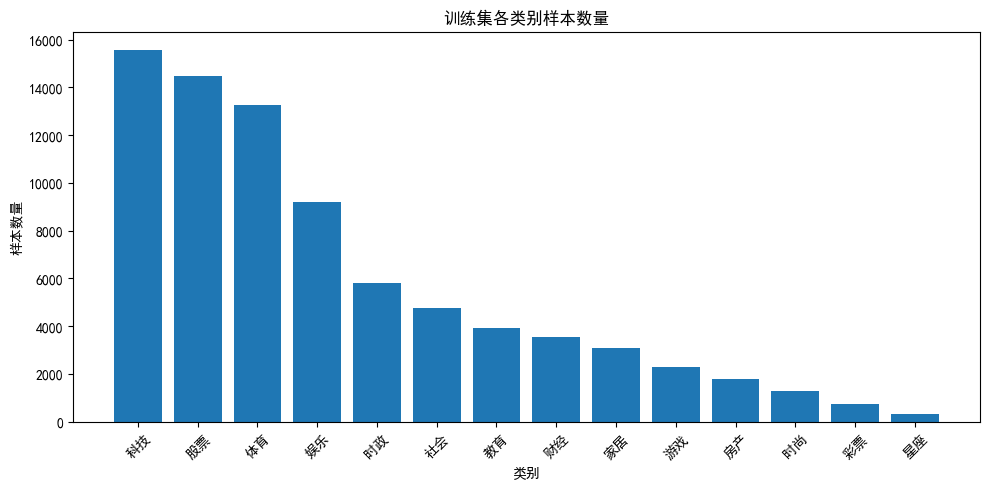

In [62]:
# 训练集类别分布柱状图
label_counts = train_df["label"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values)
plt.title("训练集各类别样本数量")
plt.xlabel("类别")
plt.ylabel("样本数量")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
# 每个类别随机展示若干条标题
def show_random_examples(df: pd.DataFrame, examples_per_class: int = 2) -> None:
    for label in sorted(df["label"].unique()):
        print(f"\n【{label}】")
        examples = df[df["label"] == label].sample(
            n=min(examples_per_class, (df["label"] == label).sum()),
            random_state=RANDOM_STATE
        )
        for text in examples["text"].tolist():
            print(" -", text)


show_random_examples(train_df, examples_per_class=2)


【体育】
 - 乌拉圭主帅：对高家军一无所知 应该比印尼厉害些
 - C罗未愈仍渴望助阵皇马 洛佩兹扬言将延续里昂魔咒

【娱乐】
 - 张惠妹前男友承认新恋情 高调为女友助阵
 - 邓超笑傲电视观众节排行榜 三榜单一个不落(图)

【家居】
 - 2011中国（北京）门业博览会进入倒计时
 - 达芬奇与帝王事件给中国家具业带来警示

【彩票】
 - 预计首发：埃托奥米利托领衔国米 曼联中场吃紧
 - 2.58亿得主尚未申报领奖 全市彩站被要求庆贺一周

【房产】
 - 通州天朗雅园在售87平米1居现房均价8050元(图)
 - 东四环北京华侨城5月开盘推3-4居新房源(图)

【教育】
 - 广东海洋大学2010年硕士研究生招生简章
 - 趣味测试：经典豪宅盗窃推理谜题(图)

【时尚】
 - 组图：明星推荐不怕坐皱的OL裙
 - 组图：藏起肥臀蓬裙自救梨型身材

【时政】
 - 裴广江：索马里海盗为何仍猖獗
 - 工商总局：严厉整治媒体违法广告

【星座】
 - 爱情测试：你会因寂寞而去爱吗(图)
 - 趣味测试：你这辈子有多少贵人运(图)

【游戏】
 - 大爱迪斯尼！《经典米奇》TGS宣传片
 - 中华龙塔4.28龙吟封测 百家公会祝贺

【社会】
 - 网曝医院无扳手开氧气罐致产妇死亡(组图)
 - 警员异地刑讯逼供致人死亡被判刑

【科技】
 - 卖场最新情报 主流热水器TOP5抢先预览
 - 张亚勤：微软将在台湾成立硬体创新中心

【股票】
 - 恒指高开低走跌1.36% 报23164.03点
 - 李嘉诚增持长实17万股

【财经】
 - 推石油期货现在应是理想时机
 - 基金经理收益榜王亚伟又拿第一


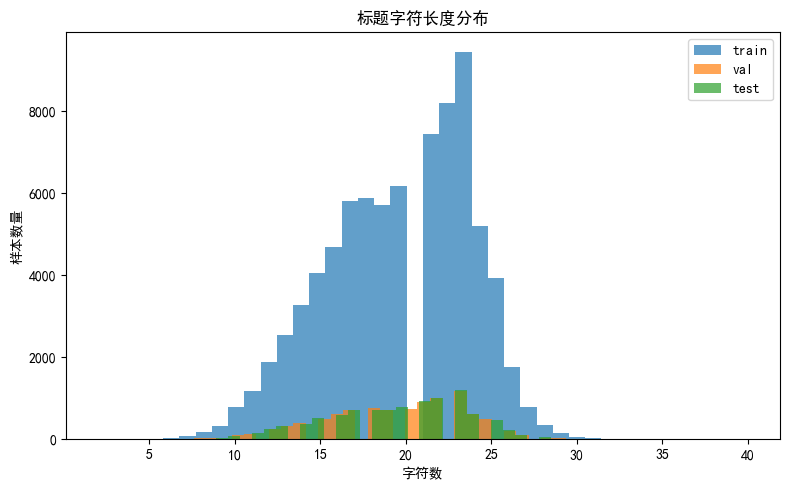

训练集标题长度统计：
count    80000.000000
mean        19.518400
std          4.074401
min          2.000000
25%         17.000000
50%         20.000000
75%         23.000000
max         40.000000
Name: text, dtype: float64


In [64]:
# 标题字符长度分布
train_lengths = train_df["text"].astype(str).str.len()
val_lengths = val_df["text"].astype(str).str.len()
test_lengths = test_df["text"].astype(str).str.len()

plt.figure(figsize=(8, 5))
plt.hist(train_lengths, bins=40, alpha=0.7, label="train")
plt.hist(val_lengths, bins=40, alpha=0.7, label="val")
plt.hist(test_lengths, bins=40, alpha=0.7, label="test")
plt.title("标题字符长度分布")
plt.xlabel("字符数")
plt.ylabel("样本数量")
plt.legend()
plt.tight_layout()
plt.show()

print("训练集标题长度统计：")
print(train_lengths.describe())

### 观察标题字符长度分布思考


请根据上方的 train / val / test 标题字符长度分布直方图，思考：

1. **大多数新闻标题集中在多少个字符左右？**  
   这说明新闻标题是长文本还是短文本？

2. **train、val、test 三个集合的长度分布是否相似？**  
   如果三者分布接近，说明数据划分有什么特点？

3. **标题过短可能会对分类造成什么影响？**  
   思考短标题是否更容易缺少关键信息，导致模型分类错误。

**小结：**  
标题长度分布可以帮助我们了解文本信息量和数据划分是否稳定。新闻标题通常较短，模型更依赖少量关键词，因此短标题可能更容易出现分类困难。

## 5. 文本预处理与分词

中文文本通常需要先分词，再进行特征提取。

本实验使用 `jieba.lcut()` 进行分词，并进行简单过滤：

1. 去除空白字符。
2. 去除停用词。
3. 保留中文、英文、数字。
4. 去除标点符号等无意义字符。


In [65]:
def load_stopwords(path: Path) -> set:
    """
    加载停用词表。
    如果停用词文件不存在，则返回空集合。
    """
    path = Path(path)
    if not path.exists():
        print(f"未找到停用词文件：{path}，将不使用停用词表。")
        return set()

    stopwords = set()
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            word = line.strip()
            if word:
                stopwords.add(word)
    return stopwords


STOPWORDS = load_stopwords(STOPWORDS_PATH)

# 匹配中文、英文、数字
TOKEN_PATTERN = re.compile(r"[\u4e00-\u9fff]+|[A-Za-z]+|\d+")


def jieba_tokenizer(text: str) -> list:
    """
    使用 jieba 对中文标题进行分词，并过滤停用词和标点符号。

    CountVectorizer 会调用该函数，将原始文本转换为 token 列表。
    """
    tokens = []
    for word in jieba.lcut(str(text)):
        word = word.strip().lower()
        if not word:
            continue

        # 一个 jieba 切分结果中可能同时包含文字和符号，这里进一步提取有效片段
        pieces = TOKEN_PATTERN.findall(word)
        for piece in pieces:
            if not piece:
                continue
            if piece in STOPWORDS:
                continue
            tokens.append(piece)

    return tokens


# 测试分词效果
example_text = train_df.iloc[0]["text"]
print("原始标题：", example_text)
print("分词结果：", jieba_tokenizer(example_text))

原始标题： 中关村攻坚哥德巴赫猜想：中小企业融资新解法
分词结果： ['中关村', '攻坚', '哥德巴赫猜想', '中小企业', '融资', '新', '解法']


## 6. 标签编码

机器学习模型通常需要使用数字标签进行训练。

这里使用 `LabelEncoder` 将类别名称转换为整数，例如：

```text
体育 -> 0
娱乐 -> 1
...
```

模型预测完成后，也可以再转换回原始类别名称。

In [66]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_df["label"])
y_val = label_encoder.transform(val_df["label"])
y_test = label_encoder.transform(test_df["label"])

label_names = label_encoder.classes_

print("类别名称：")
for idx, name in enumerate(label_names):
    print(idx, "->", name)

类别名称：
0 -> 体育
1 -> 娱乐
2 -> 家居
3 -> 彩票
4 -> 房产
5 -> 教育
6 -> 时尚
7 -> 时政
8 -> 星座
9 -> 游戏
10 -> 社会
11 -> 科技
12 -> 股票
13 -> 财经


## 7. 构建 BOW unigram 词频特征

BOW，Bag of Words，词袋模型。

它将每篇文本表示为一个词频向量。向量中的每个位置对应词汇表中的一个词，数值表示该词在当前文本中出现的次数。

本实验主线采用 **BOW 词袋模型** 作为文本特征表示。BOW 使用词频计数作为特征，与多项式朴素贝叶斯中的条件概率估计最直接对应。

本节先构建最基础的 unigram BOW 特征，即只使用单个词作为特征。后续会在 sklearn 基线模型中比较 unigram 与 unigram + bigram。

In [67]:
def build_count_features(ngram_range=(1, 1), max_features=MAX_FEATURES, min_df=MIN_DF):
    """
    根据指定 ngram_range 构建 CountVectorizer 特征。
    """
    vectorizer = CountVectorizer(
        tokenizer=jieba_tokenizer,
        token_pattern=None,      # 使用自定义 tokenizer 时需要设为 None
        max_features=max_features,
        min_df=min_df,
        ngram_range=ngram_range,
    )

    start_time = time.time()

    X_train = vectorizer.fit_transform(train_df["text"])
    X_val = vectorizer.transform(val_df["text"])
    X_test = vectorizer.transform(test_df["text"])

    elapsed = time.time() - start_time

    print(f"ngram_range={ngram_range} 特征构建完成")
    print("训练集特征矩阵形状：", X_train.shape)
    print("验证集特征矩阵形状：", X_val.shape)
    print("测试集特征矩阵形状：", X_test.shape)
    print(f"耗时：{elapsed:.2f} 秒")

    return vectorizer, X_train, X_val, X_test




## 8. 评价函数

为了便于后续比较不同模型，先定义统一的评价函数。

本实验主要报告：

- **Accuracy**：准确率，反映整体分类正确率；
- **Macro-F1**：宏平均 F1，对每个类别一视同仁，适合观察小类别表现；
- **Weighted-F1**：加权平均 F1，按照类别样本数加权，适合观察整体表现。

由于本实验数据存在类别不平衡，Accuracy 和 Weighted-F1 可能会受到多数类影响。

因此，后续调参时主要参考 **Macro-F1**，同时结合 Accuracy、Weighted-F1、分类报告和混淆矩阵进行分析。


In [68]:
def evaluate_predictions(y_true, y_pred, label_names=None, title="模型结果", show_report=True):
    """
    评价分类结果。
    """
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"===== {title} =====")
    print(f"Accuracy    : {acc:.4f}")
    print(f"Macro-P     : {macro_precision:.4f}")
    print(f"Macro-R     : {macro_recall:.4f}")
    print(f"Macro-F1    : {macro_f1:.4f}")
    print(f"Weighted-F1 : {weighted_f1:.4f}")

    if show_report and label_names is not None:
        print("\n分类报告：")
        print(classification_report(
            y_true,
            y_pred,
            target_names=label_names,
            digits=4,
            zero_division=0
        ))

    return {
        "accuracy": acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }

In [69]:
bow_vectorizer, X_train_bow, X_val_bow, X_test_bow = build_count_features(ngram_range=(1, 1))

# CountVectorizer 会把每个词映射到特征矩阵中的一个列编号。
# 例如：如果 vocab["手机"] = 4836，表示“手机”这个词对应特征矩阵的第 4836 列。
if hasattr(bow_vectorizer, "get_feature_names_out"):
    feature_names = bow_vectorizer.get_feature_names_out()
else:
    feature_names = bow_vectorizer.get_feature_names()
vocab = bow_vectorizer.vocabulary_

# 1）查看若干个指定中文词在词汇表中的编号
example_words = [
    "科技", "股票", "体育", "娱乐", "教育", "财经",
    "手机", "比赛", "房价", "彩票", "星座", "游戏",
    "基金", "学校", "冠军", "楼市", "政策", "银行"
 ]

word_index_df = pd.DataFrame([
    {
        "词汇": word,
        "特征编号": vocab[word] if word in vocab else "未进入词汇表"
    }
    for word in example_words
])

print("指定词汇及其特征编号：")
display(word_index_df)


ngram_range=(1, 1) 特征构建完成
训练集特征矩阵形状： (80000, 10000)
验证集特征矩阵形状： (10000, 10000)
测试集特征矩阵形状： (10000, 10000)
耗时：2.84 秒
指定词汇及其特征编号：


,词汇,特征编号
0,科技,7392
1,股票,7975
2,体育,1537
3,娱乐,3656
4,教育,5376
5,财经,8654
6,手机,4829
7,比赛,6236
8,房价,4807
9,彩票,4478


In [70]:
# 2）用一条真实新闻标题演示：标题中的词对应哪些特征编号，以及在该标题中的词频是多少
sample_idx = 0
sample_text = train_df.iloc[sample_idx]["text"]
sample_tokens = jieba_tokenizer(sample_text)
sample_token_counts = Counter(sample_tokens)

sample_rows = []
for token in dict.fromkeys(sample_tokens):  # 去掉重复展示，保留出现顺序
    in_vocab = token in vocab

    if in_vocab:
        feature_idx = vocab[token]
        matrix_count = int(X_train_bow[sample_idx, feature_idx])
        note = "已进入词汇表"
    else:
        feature_idx = "无"
        matrix_count = 0
        note = f"未进入词汇表，可能是低频词，或被 max_features={MAX_FEATURES} 截断"

    sample_rows.append({
        "词汇": token,
        "是否进入词汇表": "是" if in_vocab else "否",
        "特征编号": feature_idx,
        "标题中出现次数": sample_token_counts[token],
        "特征矩阵中的词频": matrix_count,
        "说明": note,
    })

print("示例标题：", sample_text)
print("该标题分词结果：", sample_tokens)
print("该标题中的词汇及其特征编号：")
display(pd.DataFrame(sample_rows))


示例标题： 中关村攻坚哥德巴赫猜想：中小企业融资新解法
该标题分词结果： ['中关村', '攻坚', '哥德巴赫猜想', '中小企业', '融资', '新', '解法']
该标题中的词汇及其特征编号：


,词汇,是否进入词汇表,特征编号,标题中出现次数,特征矩阵中的词频,说明
0,中关村,是,992,1,1,已进入词汇表
1,攻坚,否,无,1,0,未进入词汇表，可能是低频词，或被 max_features=10000 截断
2,哥德巴赫猜想,否,无,1,0,未进入词汇表，可能是低频词，或被 max_features=10000 截断
3,中小企业,是,1020,1,1,已进入词汇表
4,融资,是,8284,1,1,已进入词汇表
5,新,是,5435,1,1,已进入词汇表
6,解法,否,无,1,0,未进入词汇表，可能是低频词，或被 max_features=10000 截断


## 9. sklearn 基线模型：MultinomialNB

本节使用 sklearn 提供的 `MultinomialNB` 作为基线模型。

基线模型的作用：

1. 跑通完整文本分类流程。
2. 提供一个可对比的参考结果。
3. 用于完成 `alpha` 和 `n-gram` 的参数对比实验。
4. 帮助检查后续手写实现是否合理。

本节先使用最基础设置：

- 特征：BOW unigram
- `alpha = 1.0`

In [71]:
baseline_alpha = 1.0

sklearn_nb = MultinomialNB(alpha=baseline_alpha)
sklearn_nb.fit(X_train_bow, y_train)

y_val_pred_sklearn = sklearn_nb.predict(X_val_bow)

sklearn_val_metrics = evaluate_predictions(
    y_val,
    y_val_pred_sklearn,
    label_names=label_names,
    title=f"sklearn MultinomialNB 验证集结果：BOW unigram, alpha={baseline_alpha}",
    show_report=True,
)

===== sklearn MultinomialNB 验证集结果：BOW unigram, alpha=1.0 =====
Accuracy    : 0.8476
Macro-P     : 0.8225
Macro-R     : 0.7870
Macro-F1    : 0.8017
Weighted-F1 : 0.8471

分类报告：
              precision    recall  f1-score   support

          体育     0.9284    0.9318    0.9301      1656
          娱乐     0.8017    0.8849    0.8413      1147
          家居     0.7520    0.7285    0.7401       383
          彩票     0.9351    0.7660    0.8421        94
          房产     0.8854    0.7556    0.8153       225
          教育     0.8607    0.9167    0.8878       492
          时尚     0.7680    0.6076    0.6784       158
          时政     0.7702    0.8391    0.8032       727
          星座     0.7097    0.5789    0.6377        38
          游戏     0.7869    0.6667    0.7218       288
          社会     0.7718    0.8624    0.8146       596
          科技     0.8950    0.8153    0.8533      1944
          股票     0.8584    0.8707    0.8645      1810
          财经     0.7923    0.7941    0.7932       442

    accuracy 

## 10. 调参：在 sklearn 基线中比较不同 alpha

本节比较不同拉普拉斯平滑参数 `alpha` 对模型效果的影响。

请比较以下取值：

```python
[0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 10.0]
```

本节只使用 sklearn 的 `MultinomialNB` 完成比较，不要求手写模型参与调参。

本实验主要根据验证集 **Macro-F1** 选择较合适的 `alpha`，同时结合 Accuracy 和 Weighted-F1 进行综合观察。


In [72]:
def run_sklearn_alpha_experiment(alphas, X_train, y_train, X_val, y_val):
    """
    在验证集上比较 sklearn MultinomialNB 的不同 alpha。
    """
    results = []

    for alpha in alphas:
        start_time = time.time()

        model = MultinomialNB(alpha=alpha)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        elapsed = time.time() - start_time

        results.append({
            "model": "sklearn MultinomialNB",
            "feature": "BOW unigram",
            "ngram_range": (1, 1),
            "alpha": alpha,
            "accuracy": accuracy_score(y_val, y_pred),
            "macro_f1": f1_score(y_val, y_pred, average="macro"),
            "weighted_f1": f1_score(y_val, y_pred, average="weighted"),
            "time_sec": elapsed,
        })

    return pd.DataFrame(results)


sklearn_alpha_results = run_sklearn_alpha_experiment(
    ALPHA_LIST,
    X_train_bow,
    y_train,
    X_val_bow,
    y_val,
)

# 完整指标表格：用于综合比较 Accuracy、Macro-F1、Weighted-F1。
alpha_metric_table = sklearn_alpha_results.sort_values("alpha")[[
    "alpha", "accuracy", "macro_f1", "weighted_f1", "time_sec"
]].reset_index(drop=True)

alpha_metric_table


,alpha,accuracy,macro_f1,weighted_f1,time_sec
0,0.01,0.8449,0.806701,0.844517,0.012331
1,0.05,0.8516,0.811819,0.851575,0.012203
2,0.10,0.8511,0.810141,0.851175,0.012355
3,0.50,0.8516,0.809065,0.851478,0.024153
4,1.00,0.8476,0.801668,0.847087,0.011518
5,2.00,0.8397,0.787756,0.837832,0.009532
6,10.00,0.7959,0.664498,0.782290,0.010895


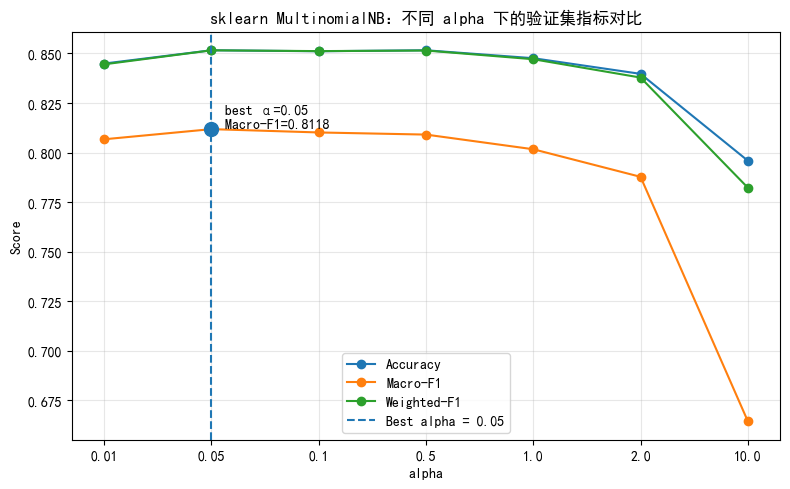

In [73]:
plt.figure(figsize=(8, 5))

alpha_plot_df = sklearn_alpha_results.sort_values("alpha").copy()
alpha_plot_df["alpha_str"] = alpha_plot_df["alpha"].astype(str)

plt.plot(alpha_plot_df["alpha_str"], alpha_plot_df["accuracy"], marker="o", label="Accuracy")
plt.plot(alpha_plot_df["alpha_str"], alpha_plot_df["macro_f1"], marker="o", label="Macro-F1")
plt.plot(alpha_plot_df["alpha_str"], alpha_plot_df["weighted_f1"], marker="o", label="Weighted-F1")

best_idx = alpha_plot_df["macro_f1"].idxmax()
best_alpha_str = alpha_plot_df.loc[best_idx, "alpha_str"]
best_macro_f1 = alpha_plot_df.loc[best_idx, "macro_f1"]

plt.axvline(best_alpha_str, linestyle="--", linewidth=1.5, label=f"Best alpha = {best_alpha_str}")
plt.scatter(best_alpha_str, best_macro_f1, s=100, zorder=5)

plt.text(
    best_alpha_str,
    best_macro_f1,
    f"  best α={best_alpha_str}\n  Macro-F1={best_macro_f1:.4f}",
    va="bottom"
)

plt.xlabel("alpha")
plt.ylabel("Score")
plt.title("sklearn MultinomialNB：不同 alpha 下的验证集指标对比")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 根据以上结果分析思考：

1. `alpha` 较小时，模型是否更依赖训练集中已经出现的词？
2. `alpha` 较大时，模型是否会过度平滑？
3. 哪个 `alpha` 在验证集上表现最好？
4. Accuracy、Macro-F1、Weighted-F1 的变化趋势是否一致？

## 11. 调参：在 sklearn 基线中比较 n-gram 特征参数

n-gram 是文本特征提取中的一个重要参数。

- `ngram_range=(1, 1)`：只使用 unigram，即单个词。
- `ngram_range=(1, 2)`：同时使用 unigram 和 bigram，即单个词与相邻两个词组成的词组。

例如，标题分词后为：

```text
中国 女排 获得 冠军
```

unigram 特征包括：

```text
中国, 女排, 获得, 冠军
```

bigram 特征包括：

```text
中国 女排, 女排 获得, 获得 冠军
```

n-gram 可以保留一部分局部词序信息，但也会增加特征维度和计算开销。

本节仍然只使用 sklearn 基线模型完成比较。为了统一比较，这里可以同时观察不同 `alpha` 与不同 `ngram_range` 的组合效果。

In [74]:
def run_sklearn_ngram_alpha_grid(
    ngram_ranges,
    alphas,
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
):
    """
    在 sklearn 基线模型中比较 n-gram 与 alpha 的组合。
    """
    results = []
    feature_cache = {}

    # 先放入前面已经构建好的 unigram BOW 特征，避免重复分词
    feature_cache[(1, 1)] = (bow_vectorizer, X_train_bow, X_val_bow, X_test_bow)

    for ngram_range in ngram_ranges:
        if ngram_range in feature_cache:
            vectorizer, X_train, X_val, X_test = feature_cache[ngram_range]
        else:
            vectorizer, X_train, X_val, X_test = build_count_features(
                ngram_range=ngram_range,
                max_features=max_features,
                min_df=min_df,
            )
            feature_cache[ngram_range] = (vectorizer, X_train, X_val, X_test)

        for alpha in alphas:
            start_time = time.time()

            model = MultinomialNB(alpha=alpha)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            elapsed = time.time() - start_time

            results.append({
                "model": "sklearn MultinomialNB",
                "feature": "BOW",
                "ngram_range": ngram_range,
                "alpha": alpha,
                "accuracy": accuracy_score(y_val, y_pred),
                "macro_f1": f1_score(y_val, y_pred, average="macro"),
                "weighted_f1": f1_score(y_val, y_pred, average="weighted"),
                "fit_predict_time_sec": elapsed,
                "n_features": X_train.shape[1],
            })

    return pd.DataFrame(results), feature_cache


sklearn_grid_results, feature_cache = run_sklearn_ngram_alpha_grid(
    NGRAM_RANGE_LIST,
    ALPHA_LIST,
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
)

sklearn_grid_results.sort_values("macro_f1", ascending=False)

ngram_range=(1, 2) 特征构建完成
训练集特征矩阵形状： (80000, 10000)
验证集特征矩阵形状： (10000, 10000)
测试集特征矩阵形状： (10000, 10000)
耗时：3.97 秒


,model,feature,ngram_range,alpha,accuracy,macro_f1,weighted_f1,fit_predict_time_sec,n_features
1,sklearn MultinomialNB,BOW,"(1, 1)",0.05,0.8516,0.811819,0.851575,0.019711,10000
2,sklearn MultinomialNB,BOW,"(1, 1)",0.10,0.8511,0.810141,0.851175,0.014109,10000
3,sklearn MultinomialNB,BOW,"(1, 1)",0.50,0.8516,0.809065,0.851478,0.008546,10000
0,sklearn MultinomialNB,BOW,"(1, 1)",0.01,0.8449,0.806701,0.844517,0.016615,10000
8,sklearn MultinomialNB,BOW,"(1, 2)",0.05,0.8435,0.803580,0.843591,0.007779,10000
9,sklearn MultinomialNB,BOW,"(1, 2)",0.10,0.8438,0.802677,0.844042,0.007728,10000
4,sklearn MultinomialNB,BOW,"(1, 1)",1.00,0.8476,0.801668,0.847087,0.008361,10000
10,sklearn MultinomialNB,BOW,"(1, 2)",0.50,0.8436,0.801263,0.843734,0.007818,10000
7,sklearn MultinomialNB,BOW,"(1, 2)",0.01,0.8400,0.800748,0.839790,0.008786,10000
11,sklearn MultinomialNB,BOW,"(1, 2)",1.00,0.8419,0.796698,0.841562,0.007802,10000


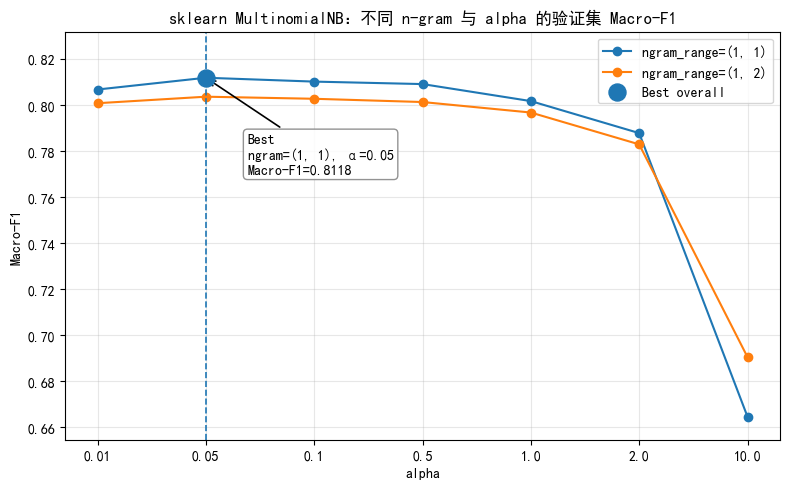

In [75]:
plt.figure(figsize=(8, 5))

# 固定 alpha 顺序，并转成字符串用于等间距显示
alpha_order = sorted(sklearn_grid_results["alpha"].unique())
alpha_labels = [str(a) for a in alpha_order]

for ngram_range, group in sklearn_grid_results.groupby("ngram_range"):
    group = group.sort_values("alpha").copy()
    group["alpha_str"] = group["alpha"].astype(str)

    plt.plot(
        group["alpha_str"],
        group["macro_f1"],
        marker="o",
        label=f"ngram_range={ngram_range}"
    )

# 找到全局最优点
best_idx = sklearn_grid_results["macro_f1"].idxmax()
best_row = sklearn_grid_results.loc[best_idx]

best_alpha = best_row["alpha"]
best_alpha_str = str(best_alpha)
best_macro_f1 = best_row["macro_f1"]
best_ngram = best_row["ngram_range"]

# 标出最优点
plt.scatter(
    best_alpha_str,
    best_macro_f1,
    s=150,
    zorder=6,
    label="Best overall"
)

# 竖线标出最优 alpha
plt.axvline(
    best_alpha_str,
    linestyle="--",
    linewidth=1.2
)

# 注释框
plt.annotate(
    f"Best\nngram={best_ngram}, α={best_alpha}\nMacro-F1={best_macro_f1:.4f}",
    xy=(best_alpha_str, best_macro_f1),
    xytext=(30, -40),
    textcoords="offset points",
    ha="left",
    va="top",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.2
    ),
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white",
        ec="gray",
        alpha=0.85
    )
)

plt.xlabel("alpha")
plt.ylabel("Macro-F1")
plt.title("sklearn MultinomialNB：不同 n-gram 与 alpha 的验证集 Macro-F1")

plt.ylim(
    sklearn_grid_results["macro_f1"].min() - 0.01,
    sklearn_grid_results["macro_f1"].max() + 0.02
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 根据以上结果分析思考：

请结合上面的验证集结果，回答以下问题：

1. 本实验中，`ngram_range=(1, 2)` 是否优于 `ngram_range=(1, 1)`？
2. 你认为造成这种结果的可能原因是什么？

**提示：**

n-gram 不一定总能提升效果。 它可以保留一定的局部词序信息，但也会增加特征空间。

在 `max_features` 固定的情况下，加入 bigram 后，部分 bigram 特征可能会占用词汇表名额，从而挤掉一些有用的 unigram 特征，导致模型效果不升反降。

## 12. sklearn 基线模型的测试集最终评估

请根据验证集结果选择较优的 `alpha` 和 `ngram_range`，然后在测试集上进行最终评估。

注意：

- 验证集用于选择参数。
- 测试集只用于最终评估。
- 不要根据测试集结果反复修改参数。

In [76]:
# 根据验证集 Macro-F1 选择 sklearn 基线模型的较优参数组合
best_sklearn_row = sklearn_grid_results.sort_values("macro_f1", ascending=False).iloc[0]

best_alpha_sklearn = float(best_sklearn_row["alpha"])
best_ngram_range = best_sklearn_row["ngram_range"]

print("验证集上选择的 best_alpha_sklearn =", best_alpha_sklearn)
print("验证集上选择的 best_ngram_range =", best_ngram_range)

best_vectorizer, X_train_best, X_val_best, X_test_best = feature_cache[best_ngram_range]

final_sklearn_model = MultinomialNB(alpha=best_alpha_sklearn)
final_sklearn_model.fit(X_train_best, y_train)

y_test_pred_sklearn_best = final_sklearn_model.predict(X_test_best)

sklearn_test_metrics = evaluate_predictions(
    y_test,
    y_test_pred_sklearn_best,
    label_names=label_names,
    title=f"sklearn MultinomialNB 测试集结果：ngram_range={best_ngram_range}, alpha={best_alpha_sklearn}",
    show_report=True,
)

验证集上选择的 best_alpha_sklearn = 0.05
验证集上选择的 best_ngram_range = (1, 1)
===== sklearn MultinomialNB 测试集结果：ngram_range=(1, 1), alpha=0.05 =====
Accuracy    : 0.8489
Macro-P     : 0.8217
Macro-R     : 0.8243
Macro-F1    : 0.8209
Weighted-F1 : 0.8488

分类报告：
              precision    recall  f1-score   support

          体育     0.9258    0.9342    0.9300      1656
          娱乐     0.8157    0.8684    0.8412      1147
          家居     0.7297    0.7258    0.7277       383
          彩票     0.9375    0.7979    0.8621        94
          房产     0.8622    0.7511    0.8029       225
          教育     0.9115    0.9207    0.9161       492
          时尚     0.7318    0.8291    0.7774       158
          时政     0.7918    0.8267    0.8089       727
          星座     0.7234    0.8947    0.8000        38
          游戏     0.7717    0.6806    0.7232       288
          社会     0.7766    0.8574    0.8150       596
          科技     0.8872    0.8215    0.8531      1944
          股票     0.8568    0.8624    0.8596   

### 思考：测试集结果与验证集结果是否接近？这说明模型泛化能力如何？

## 13. 手写 MultinomialNB

本节需要补全多项式朴素贝叶斯分类器。

手写模型只需要在固定设置下运行：

- 特征：BOW unigram
- `alpha = 1.0`

手写模型不参与前面的 `alpha` 和 `n-gram` 参数搜索，但需要完成：

- 训练集训练
- 验证集评估
- 测试集评估
- 与 sklearn 在相同设置下的结果比较

### 13.1 数学公式

对于一篇文本 $x$，朴素贝叶斯选择后验概率最大的类别：

$$
\hat{c} = \arg\max_c P(c \mid x)
$$

根据贝叶斯公式，并忽略对所有类别相同的 $P(x)$，可写为：

$$
\hat{c} = \arg\max_c P(c) P(x \mid c)
$$

在 BOW 表示下，文本由多个词组成。多项式朴素贝叶斯通常写为：

$$
\hat{c} = \arg\max_c \left[ \log P(c) + \sum_{j=1}^{V} x_j \log P(w_j \mid c) \right]
$$

其中：

- $V$：词汇表大小
- $x_j$：当前文本中第 $j$ 个词出现的次数
- $P(c)$：类别先验概率
- $P(w_j \mid c)$：类别 $c$ 下词 $w_j$ 的条件概率

> 实现时，我们只需要计算上式中的未归一化类别对数得分，并选择得分最大的类别。这个得分不等同于 sklearn 中严格归一化后的 `predict_log_proba`，但用于分类预测已经足够。

### 13.2 拉普拉斯平滑

为了避免某个词在某类中没有出现导致概率为 0，需要使用拉普拉斯平滑：

$$
P(w_j \mid c) =
\frac{N_{cj} + \alpha}
{\sum_{j=1}^{V} N_{cj} + \alpha V}
$$

其中：

- $N_{cj}$：类别 $c$ 中词 $w_j$ 的总出现次数
- $\alpha$：平滑参数
- $V$：词汇表大小


In [77]:
class MyMultinomialNB:
    """
    手写多项式朴素贝叶斯分类器。

    需要补全 TODO 部分。

    参数
    ----
    alpha : float
        拉普拉斯平滑参数。
    """

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        """
        训练模型。

        参数
        ----
        X : scipy sparse matrix 或 ndarray, shape = (n_samples, n_features)
            BOW 词频特征矩阵。
        y : ndarray, shape = (n_samples,)
            数字形式的类别标签。
        """
        if not sparse.issparse(X):
            X = sparse.csr_matrix(X)
        X = X.tocsr()
        y = np.asarray(y)

        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        self.n_features_ = n_features
        self.class_log_prior_ = np.zeros(n_classes, dtype=np.float64)
        self.feature_log_prob_ = np.zeros((n_classes, n_features), dtype=np.float64)

        for class_index, c in enumerate(self.classes_):
            # 取出当前类别 c 的所有样本
            X_c = X[y == c]
            n_c = X_c.shape[0]
        
            # TODO 1:
            # 计算类别先验概率的对数 log P(c)
            # 提示:
            # P(c) = 当前类别样本数 / 总样本数
            self.class_log_prior_[class_index] = np.log(n_c / n_samples)
        
            # TODO 2:
            # 统计当前类别下每个词的总出现次数 N_cj
            # 提示:
            # X_c.sum(axis=0) 可以得到当前类别中每个特征的词频总和
            # 注意将结果转换为一维数组，例如 np.asarray(...).ravel()
            word_count = np.asarray(X_c.sum(axis=0)).ravel()
        
            # TODO 3:
            # 使用拉普拉斯平滑计算 P(w_j | c)
            # 分子: word_count + alpha
            # 分母: 当前类别下所有词的总出现次数 + alpha * 词汇表大小
            # 最后保存 log P(w_j | c)
            smoothed_word_count = word_count + self.alpha
            smoothed_total_count = word_count.sum() + self.alpha * n_features
            self.feature_log_prob_[class_index, :] = np.log(
                smoothed_word_count / smoothed_total_count
            )
        
        return self

    def predict_log_scores(self, X):
        """
        计算每个样本属于每个类别的未归一化对数得分。

        注意：这里返回的是
        log P(c) + sum_j x_j * log P(w_j | c)，
        不是 sklearn 中严格意义上的归一化 log probability。
        对分类任务来说，直接对该得分取 argmax 即可。

        返回
        ----
        log_scores : ndarray, shape = (n_samples, n_classes)
            每个样本在每个类别上的未归一化对数得分。
        """
        self._check_is_fitted()

        if not sparse.issparse(X):
            X = sparse.csr_matrix(X)
        X = X.tocsr()

        # TODO 4：
        # 根据公式计算未归一化对数得分：
        # log P(c) + sum_j x_j * log P(w_j | c)
        #
        # 提示：
        # X 的形状为 (n_samples, n_features)
        # self.feature_log_prob_.T 的形状为 (n_features, n_classes)
        # 两者矩阵乘法得到 (n_samples, n_classes)
        log_scores = X.dot(self.feature_log_prob_.T) + self.class_log_prior_

        return log_scores

    def predict(self, X):
        """
        预测类别。
        """
        log_scores = self.predict_log_scores(X)

        # TODO 5：
        # 对每个样本，选择对数得分最大的类别
        # 提示：np.argmax(..., axis=1)
        pred_indices = np.argmax(log_scores, axis=1)
        
        return self.classes_[pred_indices]

    def _check_is_fitted(self):
        required_attrs = ["classes_", "class_log_prior_", "feature_log_prob_"]
        for attr in required_attrs:
            if not hasattr(self, attr):
                raise RuntimeError("模型尚未训练，请先调用 fit()。")

### 13.3 检查手写模型

补全 `MyMultinomialNB` 后，运行下面的代码。

在相同的 `BOW unigram` 特征和相同的 `alpha=1.0` 下，分别比较 sklearn 与手写模型在验证集和测试集上的表现。手写模型的结果应与 sklearn 同设置模型接近。

In [78]:
my_alpha = 1.0

# =========================
# 1. sklearn 对照模型：BOW unigram + alpha=1.0
# =========================
sklearn_nb_for_compare = MultinomialNB(alpha=my_alpha)
sklearn_nb_for_compare.fit(X_train_bow, y_train)

y_val_pred_sklearn_compare = sklearn_nb_for_compare.predict(X_val_bow)
y_test_pred_sklearn_compare = sklearn_nb_for_compare.predict(X_test_bow)

sklearn_compare_val_metrics = evaluate_predictions(
    y_val,
    y_val_pred_sklearn_compare,
    label_names=label_names,
    title=f"sklearn MultinomialNB 验证集结果：BOW unigram, alpha={my_alpha}",
    show_report=False,
)

sklearn_compare_test_metrics = evaluate_predictions(
    y_test,
    y_test_pred_sklearn_compare,
    label_names=label_names,
    title=f"sklearn MultinomialNB 测试集结果：BOW unigram, alpha={my_alpha}",
    show_report=True,
)

# =========================
# 2. 手写模型：BOW unigram + alpha=1.0
# =========================
my_nb = MyMultinomialNB(alpha=my_alpha)
my_nb.fit(X_train_bow, y_train)

y_val_pred_my = my_nb.predict(X_val_bow)
y_test_pred_my = my_nb.predict(X_test_bow)

my_val_metrics = evaluate_predictions(
    y_val,
    y_val_pred_my,
    label_names=label_names,
    title=f"MyMultinomialNB 验证集结果：BOW unigram, alpha={my_alpha}",
    show_report=False,
)

my_test_metrics = evaluate_predictions(
    y_test,
    y_test_pred_my,
    label_names=label_names,
    title=f"MyMultinomialNB 测试集结果：BOW unigram, alpha={my_alpha}",
    show_report=True,
)


===== sklearn MultinomialNB 验证集结果：BOW unigram, alpha=1.0 =====
Accuracy    : 0.8476
Macro-P     : 0.8225
Macro-R     : 0.7870
Macro-F1    : 0.8017
Weighted-F1 : 0.8471
===== sklearn MultinomialNB 测试集结果：BOW unigram, alpha=1.0 =====
Accuracy    : 0.8508
Macro-P     : 0.8412
Macro-R     : 0.8042
Macro-F1    : 0.8198
Weighted-F1 : 0.8503

分类报告：
              precision    recall  f1-score   support

          体育     0.9293    0.9293    0.9293      1656
          娱乐     0.8169    0.8910    0.8524      1147
          家居     0.7603    0.7206    0.7399       383
          彩票     0.9315    0.7234    0.8144        94
          房产     0.8769    0.7600    0.8143       225
          教育     0.8686    0.9268    0.8968       492
          时尚     0.7908    0.7658    0.7781       158
          时政     0.7979    0.8308    0.8140       727
          星座     0.9032    0.7368    0.8116        38
          游戏     0.7941    0.6562    0.7186       288
          社会     0.7604    0.8574    0.8060       596
        

In [79]:
# 比较 sklearn 实现和手写实现：验证集 + 测试集
comparison_df = pd.DataFrame([
    {
        "model": "sklearn MultinomialNB",
        "split": "val",
        "feature": "BOW unigram",
        "alpha": my_alpha,
        **sklearn_compare_val_metrics,
    },
    {
        "model": "sklearn MultinomialNB",
        "split": "test",
        "feature": "BOW unigram",
        "alpha": my_alpha,
        **sklearn_compare_test_metrics,
    },
    {
        "model": "MyMultinomialNB",
        "split": "val",
        "feature": "BOW unigram",
        "alpha": my_alpha,
        **my_val_metrics,
    },
    {
        "model": "MyMultinomialNB",
        "split": "test",
        "feature": "BOW unigram",
        "alpha": my_alpha,
        **my_test_metrics,
    },
])

comparison_df


,model,split,feature,alpha,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,sklearn MultinomialNB,val,BOW unigram,1.0,0.8476,0.822539,0.787012,0.801668,0.847087
1,sklearn MultinomialNB,test,BOW unigram,1.0,0.8508,0.841212,0.804171,0.819753,0.850279
2,MyMultinomialNB,val,BOW unigram,1.0,0.8476,0.822539,0.787012,0.801668,0.847087
3,MyMultinomialNB,test,BOW unigram,1.0,0.8508,0.841212,0.804171,0.819753,0.850279


# 选做部分

以下内容为选做。完成必做任务后，可选择其中若干项进行扩展实验。

选做部分只提供思路和代码框架，请根据提示补全 TODO 后再运行。


## 选做 A：绘制混淆矩阵

混淆矩阵可以帮助观察哪些类别之间容易混淆。

如果类别较多，图中数字可能较密集。可以重点观察颜色较深的非对角线位置。

请补全下面的 TODO，绘制 sklearn 最优基线模型在测试集上的混淆矩阵。


In [80]:
def plot_confusion_matrix(
    y_true, y_pred, label_names, normalize=False, title="混淆矩阵"
):
    """
    TODO：补全混淆矩阵绘制函数。

    提示：
    1. 使用 confusion_matrix(y_true, y_pred) 得到混淆矩阵 cm；
    2. 如果 normalize=True，对 cm 按行归一化；
    3. 使用 plt.imshow(...) 绘制矩阵；
    4. 设置 x 轴为预测类别，y 轴为真实类别。
    """
    # TODO: 计算混淆矩阵
    ...  # 请补全

    plt.show()


# 测试
plot_confusion_matrix(
    y_test,
    y_test_pred_sklearn_best,
    label_names=label_names,
    normalize=True,
    title="sklearn 最优基线模型：测试集归一化混淆矩阵",
)


In [81]:
# TODO：找出混淆较严重的类别对。
#
# 提示：
# 1. 使用 confusion_matrix(y_test, y_test_pred_sklearn_best) 得到 cm；
# 2. 遍历 cm 中的非对角线元素；
# 3. 将 “数量、真实类别、预测类别” 保存到列表；
# 4. 按数量从大到小排序，输出前 10 个。

...  # 请补全


Ellipsis

## 选做 B：错误样本分析

可以抽取若干个错误分类样本，观察错误原因。

常见原因包括：

1. 标题过短，信息不足。
2. 多个类别共享相似关键词。
3. 标题中存在罕见词或新词。
4. 分词结果不理想。
5. 类别本身边界较模糊。

In [82]:
def show_error_examples(df, y_true, y_pred, label_names, n=20):
    """
    TODO：抽取并展示错误分类样本。

    提示：
    1. 使用 np.where(y_true != y_pred)[0] 找到错误样本下标；
    2. 从错误下标中随机抽取 n 个；
    3. 返回包含 text、true_label、pred_label 的 DataFrame。
    """
    ...  # 请补全


# 测试
error_examples_df = show_error_examples(
    test_df, y_test, y_test_pred_sklearn_best, label_names, n=20
)
error_examples_df


## 选做 C：BOW 与 TF-IDF 对比

BOW 和 TF-IDF 的分词过程可以相同，区别在于向量化方式：

- BOW：使用词频计数。
- TF-IDF：使用加权后的词频分数，降低常见词权重，突出区分性较强的词。

多项式朴素贝叶斯与 BOW 的概率解释更直接，因此本实验主线采用 BOW。TF-IDF 可作为扩展实验进行对比。

In [83]:
# TODO：完成 BOW 与 TF-IDF 的对比实验。
#
# 提示：
# 1. 将 CountVectorizer 替换为 TfidfVectorizer；
# 2. 训练集使用 fit_transform，验证集/测试集使用 transform；
# 3. 使用与 sklearn 最优基线相同或自行选择的 alpha 训练 MultinomialNB；
# 4. 在测试集上调用 evaluate_predictions；
# 5. 对比 TF-IDF 与 BOW 的 Accuracy、Macro-F1、Weighted-F1。

tfidf_vectorizer = TfidfVectorizer(
    tokenizer=jieba_tokenizer,
    token_pattern=None,
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
)

X_train_tfidf = ...  # 请补全
X_val_tfidf = ...  # 请补全
X_test_tfidf = ...  # 请补全

tfidf_nb = ...  # 请补全
tfidf_nb.fit(...)  # 请补全
y_test_pred_tfidf = ...  # 请补全

tfidf_test_metrics = evaluate_predictions(...)  # 请补全


AttributeError: 'ellipsis' object has no attribute 'fit'

## 选做 D：其他模型对比

可以尝试线性模型，例如 LogisticRegression 或 LinearSVC。

朴素贝叶斯训练速度快、实现简单，适合作为文本分类入门模型。线性模型通常在文本分类中也有较强表现，但训练时间可能更长。

In [ ]:
# TODO：尝试其他模型，例如 LinearSVC。
#
# 提示：
# 1. 从 sklearn.svm 导入 LinearSVC；
# 2. 使用训练集特征 X_train_bow 训练模型；
# 3. 在测试集 X_test_bow 上预测；
# 4. 调用 evaluate_predictions 进行评价；
# 5. 将结果与 MultinomialNB 进行比较。

from sklearn.svm import LinearSVC

linear_svc = ...  # 请补全
linear_svc.fit(...)  # 请补全
y_test_pred_svc = ...  # 请补全

svc_test_metrics = evaluate_predictions(...)  # 请补全


===== LinearSVC 测试集结果：BOW unigram =====
Accuracy    : 0.8562
Macro-P     : 0.8363
Macro-R     : 0.8204
Macro-F1    : 0.8273
Weighted-F1 : 0.8559

分类报告：
              precision    recall  f1-score   support

          体育     0.9443    0.9318    0.9380      1656
          娱乐     0.8242    0.8422    0.8331      1147
          家居     0.7577    0.7023    0.7290       383
          彩票     0.9136    0.7872    0.8457        94
          房产     0.7965    0.8000    0.7982       225
          教育     0.9321    0.9207    0.9264       492
          时尚     0.6978    0.8038    0.7471       158
          时政     0.8459    0.8157    0.8305       727
          星座     0.8919    0.8684    0.8800        38
          游戏     0.7765    0.6875    0.7293       288
          社会     0.7939    0.7886    0.7912       596
          科技     0.8703    0.8699    0.8701      1944
          股票     0.8464    0.8978    0.8713      1810
          财经     0.8173    0.7692    0.7925       442

    accuracy                        